# Neural Search Engine for Text Retrieval

**Project Report**

---

## 1. Introduction & Problem Statement

The goal of this project is to build a **neural search engine** that, given a natural-language query, retrieves the most relevant text passages from a large corpus.

This is a core problem in Natural Language Processing known as **passage retrieval** (or dense retrieval). Traditional approaches rely on lexical matching (exact word overlap), while modern neural approaches learn dense vector representations that capture semantic similarity — so a query like *"what causes a cold"* can match a passage that says *"viral upper respiratory tract infection"* even without shared words.

We implement and compare three retrieval methods:
1. **TF-IDF** — a strong sparse/lexical baseline
2. **Bag-of-Words (BoW) cosine** — a simpler sparse baseline without IDF weighting
3. **BiLSTM bi-encoder** — a dense neural model trained from scratch using contrastive learning

## 2. Dataset

### 2.1 Data Source

We use **MS MARCO (Microsoft Machine Reading Comprehension)** v1.1, a large-scale real-world information retrieval dataset from Hugging Face (`microsoft/ms_marco`, config `v1.1`).

### 2.2 What is a Query and a Document?

- **Query**: A real search query typed by users on Bing (e.g., *"what causes a cold"*, *"how does photosynthesis work"*)
- **Document**: A short passage (typically 50–300 words) extracted from web pages that were retrieved by Bing for that query
- Each query has multiple candidate passages, and human annotators marked which passages actually answer the query (`is_selected = 1`)

### 2.3 Train / Validation / Test Splits

The splits come directly from the MS MARCO dataset (pre-defined by Microsoft):

| Split | Role | Query–passage pairs |
|-------|------|--------------------:|
| `train` | Model training | 88,523 |
| `validation` | Hyperparameter tuning, early stopping | 10,783 |
| `test` | Final held-out evaluation | 10,448 |

We extract only **(query, positive passage)** pairs — i.e., pairs where the passage is marked as relevant. The data is saved as JSONL files via `scripts/build_msmarco_pairs.py`.

### 2.4 Why MS MARCO?

MS MARCO is the standard benchmark for passage retrieval because:
- **Real queries** from a commercial search engine (not synthetic)
- **Human-annotated** relevance judgments
- **Large scale** — enough data to train a neural model from scratch
- **Standard metrics** (MRR, Recall@k) are well-established on this dataset, making our results comparable to published work

## 3. Baseline Methods

### 3.1 TF-IDF

**TF-IDF (Term Frequency — Inverse Document Frequency)** is a classic information retrieval method. Each passage and query is represented as a sparse vector where each dimension corresponds to a word in the vocabulary.

- **TF** (sublinear): $1 + \log(\text{count})$ — diminishing returns for repeated words
- **IDF**: $\log\frac{N}{df_t}$ — down-weights common words like "the", "is"
- Retrieval: cosine similarity between the query vector and each document vector

Implementation: `sklearn.TfidfVectorizer` with `max_features=65,536` and `sublinear_tf=True` (see `src/tfidf_retrieval.py`).

### 3.2 Bag-of-Words Cosine

A simpler baseline using raw word counts (no IDF weighting):
- **CountVectorizer** builds word-count vectors
- Rows are **L2-normalized** so the dot product equals cosine similarity
- Without IDF, common words are not down-weighted, which makes this a weaker baseline — included to show the value of IDF

Implementation: `sklearn.CountVectorizer` + `sklearn.preprocessing.normalize` (see `src/bow_retrieval.py`).

## 4. Model Architecture: BiLSTM Bi-Encoder

### 4.1 Why a Bi-Encoder?

In retrieval, we need to score a query against potentially hundreds of thousands of documents. There are two main neural approaches:

- **Cross-encoder**: Concatenates query and document, passes them through one network together. Very accurate but extremely slow — must run the full model for every (query, document) pair at retrieval time.
- **Bi-encoder**: Encodes query and document **independently** into fixed-size vectors, then scores them via a simple dot product.

We chose a **bi-encoder** because:
- All document embeddings can be **precomputed once** and stored (we encode 105,793 passages in ~90 seconds)
- At query time, we only encode the query (one forward pass) and compute dot products against all precomputed document vectors — this is a single matrix multiplication, making retrieval extremely fast
- This is the standard architecture used in production retrieval systems (e.g., Facebook's DPR, Google's dual encoders)

The trade-off is that the query and document don't "see" each other during encoding, so the model can't do fine-grained token-level matching. But for first-stage retrieval over large corpora, this efficiency is essential.

### 4.2 Why BiLSTM (not a Pretrained Transformer)?

We deliberately chose to **train a model from scratch** rather than fine-tuning a pretrained model like DistilBERT. This demonstrates:
- Understanding of neural architecture design choices
- How contrastive learning works starting from random initialization
- The impact of architecture choices on retrieval quality

A **bidirectional LSTM** was chosen because:
- It captures **sequential context** in both directions — unlike bag-of-words, the LSTM understands that "bank" in "river bank" means something different from "bank" in "bank account" because it sees the surrounding words
- It is **lightweight** enough to train from scratch on a laptop (~16M parameters vs ~66M for DistilBERT)
- It provides a good balance between expressiveness and computational cost
- LSTMs have a well-understood training behavior and don't require the careful learning rate scheduling that Transformers need



### 4.3 Architecture Overview

```
Input text: "what causes a cold"
         │
         ▼
  ┌─────────────────────────────────┐
  │  Step 1: Word Tokenization      │
  │  "what causes a cold"           │
  │       → ["what", "causes",      │
  │          "a", "cold"]           │
  └─────────────────────────────────┘
         │
         ▼
  ┌─────────────────────────────────┐
  │  Step 2: Vocabulary Lookup      │
  │  ["what","causes","a","cold"]   │
  │       → [15, 892, 3, 1047]     │
  └─────────────────────────────────┘
         │
         ▼
  ┌─────────────────────────────────┐
  │  Step 3: Embedding Layer        │
  │  Each ID → 300-dim vector       │
  │  Shape: [4, 300]               │
  └─────────────────────────────────┘
         │
         ▼
  ┌─────────────────────────────────┐
  │  Step 4: Dropout (p=0.1)        │
  └─────────────────────────────────┘
         │
         ▼
  ┌─────────────────────────────────┐
  │  Step 5: Bidirectional LSTM     │
  │  Forward:  → → → → (256-dim)   │
  │  Backward: ← ← ← ← (256-dim)  │
  │  Concat: 512-dim per position  │
  │  Shape: [4, 512]               │
  └─────────────────────────────────┘
         │
         ▼
  ┌─────────────────────────────────┐
  │  Step 6: Mean Pooling           │
  │  Average over 4 positions       │
  │  (ignoring any <pad> tokens)    │
  │  Shape: [512]                  │
  └─────────────────────────────────┘
         │
         ▼
  ┌─────────────────────────────────┐
  │  Step 7: Linear Projection      │
  │  512 → 256                     │
  │  Shape: [256]                  │
  └─────────────────────────────────┘
         │
         ▼
  ┌─────────────────────────────────┐
  │  Step 8: L2 Normalization       │
  │  ||v|| = 1 (unit vector)       │
  │  Shape: [256]                  │
  └─────────────────────────────────┘
         │
         ▼
    Final embedding: 256-dim unit vector
```

The **same encoder** (shared weights) is used for both queries and documents. Below we explain each step in detail.

### 4.4 Step-by-Step Explanation

#### Step 1: Tokenization (`src/vocab.py → tokenize()`)

The input text is converted to lowercase and split into words using a simple regex: `[a-z0-9]+`. This splits on any non-alphanumeric character.

Example: `"What's the temperature?"` → `["what", "s", "the", "temperature"]`

This is deliberately simple — no subword tokenization (like BPE or WordPiece), no lemmatization, no stopword removal. We wanted the model to learn what matters from the data itself.

#### Step 2: Vocabulary Lookup (`src/vocab.py → Vocabulary`)

We build a word-to-integer mapping from the training corpus:
- Count every word across all 88,523 training pairs (both queries and passages)
- Keep the top **50,000** most frequent words that appear at least **2 times**
- Two special tokens: `<pad>` (ID=0, for padding shorter sequences) and `<unk>` (ID=1, for unknown words not in vocabulary)
- Final vocabulary size: **50,002** tokens

Words not in the vocabulary (rare words, typos, etc.) are mapped to `<unk>`. For example, if "immunodeficiency" never appeared in training, it becomes `<unk>`.

Sequences are **truncated** to a maximum length (32 tokens for queries, 128 for documents) and **padded** with `<pad>` tokens if shorter. An **attention mask** tensor tracks which positions are real tokens (1) vs padding (0).

#### Step 3: Embedding Layer (`nn.Embedding`)

Each token ID is looked up in an **embedding matrix** of shape `[50002, 300]` — every word in the vocabulary has its own learnable 300-dimensional vector.

These embeddings are **randomly initialized** (not pretrained). The model learns word representations entirely from the retrieval task. Over training, semantically similar words end up with similar embedding vectors.

The `padding_idx=0` parameter ensures the `<pad>` token always has a zero vector and its embedding is never updated during training.

#### Step 4: Dropout

A dropout layer randomly zeros out 10% of the embedding dimensions during training. This is a regularization technique that prevents the model from relying too heavily on any single feature, reducing overfitting.

During evaluation/inference, dropout is disabled (all values are kept).

#### Step 5: Bidirectional LSTM

This is the core of the model. An **LSTM (Long Short-Term Memory)** is a recurrent neural network that processes the sequence one token at a time, maintaining a hidden state that accumulates information from previous tokens.

**Why "bidirectional"?** A regular (forward) LSTM only sees tokens to the left. A **bidirectional** LSTM runs two LSTMs:
- **Forward LSTM**: reads left→right ("what" → "causes" → "a" → "cold"), producing a 256-dim hidden state at each position
- **Backward LSTM**: reads right→left ("cold" → "a" → "causes" → "what"), producing another 256-dim hidden state at each position

At each position, the forward and backward hidden states are **concatenated** into a 512-dim vector. This means every token's representation is informed by the **entire sequence** — both what comes before and after it.

**LSTM internals** (simplified): At each time step $t$, the LSTM decides:
- **Forget gate**: How much of the previous memory to keep (e.g., forget irrelevant earlier context)
- **Input gate**: How much of the new input to store (e.g., "cold" is important)
- **Output gate**: How much of the memory to expose as the hidden state

This gating mechanism lets the LSTM selectively remember long-range dependencies — crucial for understanding that "cold" in "what causes a cold" refers to a disease, not a temperature.

**Packed sequences**: Since sequences in a batch have different lengths (some queries are 3 words, others are 30), we use PyTorch's `pack_padded_sequence` to avoid wasting computation on padding tokens. The LSTM skips `<pad>` positions entirely.

**Parameters**: Hidden size = 256 per direction, 1 layer, no intra-layer dropout (only applicable for multi-layer LSTMs).

#### Step 6: Mean Pooling

The LSTM produces a 512-dim vector at **every position** in the sequence. But we need a single fixed-size vector to represent the entire text. We use **mean pooling**: average all the non-padding positions.

$$\\text{pooled} = \\frac{\\sum_{t=1}^{L} h_t \\cdot m_t}{\\sum_{t=1}^{L} m_t}$$

where $h_t$ is the 512-dim hidden state at position $t$, $m_t$ is the attention mask (1 for real tokens, 0 for padding), and $L$ is the sequence length.

**Why mean pooling?** Alternatives include:
- **Last hidden state**: Only captures the end of the sequence, biased toward final words
- **Max pooling**: Takes the maximum value per dimension, can be dominated by outlier tokens
- **[CLS] token pooling**: Used in BERT-style models, but requires a special token
- **Mean pooling**: Treats all tokens equally, gives a balanced representation of the entire text — simple and effective

#### Step 7: Linear Projection

A fully connected layer maps the 512-dim pooled vector down to **256 dimensions**: $\\text{proj}(x) = Wx + b$ where $W \\in \\mathbb{R}^{256 \\times 512}$.

**Why project?** Two reasons:
1. **Dimensionality reduction**: Smaller embeddings are faster to compare (256-dim dot products vs 512-dim) and use less memory when storing millions of document embeddings
2. **Learnable bottleneck**: Forces the model to compress the most important information into fewer dimensions, which can improve generalization

#### Step 8: L2 Normalization

The final vector is normalized to have unit length: $v = \\frac{v}{\\|v\\|_2}$

This means every embedding lies on the surface of a 256-dimensional unit sphere. After normalization, the **dot product** between two vectors equals their **cosine similarity**:

$$q \\cdot d = \\cos(\\theta)$$

This is essential because:
- Cosine similarity ranges from -1 to 1, making scores comparable across different queries
- It decouples direction (meaning) from magnitude (irrelevant), so the model focuses purely on semantic similarity
- It works well with the InfoNCE loss, which uses dot products as logits

### 4.5 Weight Sharing

The **same encoder** (same weights) processes both queries and documents. This means:
- A word like "cold" gets the same embedding whether it appears in a query or a document
- The LSTM and projection layers are shared, so the model learns a single unified embedding space
- This halves the number of parameters compared to using separate encoders

### 4.6 Parameter Count

| Component | Parameters | Calculation |
|-----------|----------:|-------------|
| Embedding | 15,000,600 | 50,002 × 300 |
| LSTM | 1,142,784 | 4 × (300 × 256 + 256 × 256 + 256) × 2 directions |
| Projection | 131,328 | 512 × 256 + 256 |
| **Total** | **16,274,712** | All trainable |

The embedding layer dominates (92% of parameters) — this is typical for models with large vocabularies and no pretrained embeddings.

Implementation: `src/lstm_encoder.py` (model), `src/vocab.py` (tokenizer).

## 5. Loss Function: InfoNCE

### 5.1 Why Contrastive Learning?

In retrieval, we don't have explicit "scores" for query–document pairs — we only know which documents are relevant (positive) and which are not. **Contrastive learning** trains the model to:
- Pull the query embedding **close** to its relevant document embedding
- Push it **away** from irrelevant document embeddings

### 5.2 InfoNCE Loss

Given a batch of $B$ (query, positive document) pairs with L2-normalized embeddings $q_i, d_i \in \mathbb{R}^H$:

1. Compute the similarity matrix: $S_{ij} = \frac{q_i^\top d_j}{\tau}$ where $\tau = 0.05$ is the temperature
2. Each row $i$ has **one positive** (the diagonal $S_{ii}$) and **$B-1$ in-batch negatives** (all other documents in the same batch)
3. Apply cross-entropy loss with labels $= [0, 1, 2, \ldots, B-1]$

We use **symmetric InfoNCE**: average the query→document loss with the document→query loss (transpose the similarity matrix). This provides twice the learning signal per batch.

### 5.3 Why InfoNCE?

- **No hard negatives needed** — uses in-batch negatives, which scale naturally with batch size
- **Well-suited to retrieval** — directly optimizes for ranking relevant documents higher
- **Temperature** controls the sharpness of the distribution: $\tau = 0.05$ makes the model very sensitive to small similarity differences, encouraging well-separated embeddings
- Large batch size (128) provides many in-batch negatives per query

Implementation: `src/infonce_loss.py`.

## 6. Training Process

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path(".").resolve()
if "notebooks" in str(ROOT):
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

LOG_PATH = ROOT / "checkpoints" / "lstm_msmarco" / "training_log.jsonl"

### 6.1 Hyperparameters

| Hyperparameter | Value | Rationale |
|----------------|-------|-----------|
| Epochs | 15 | Enough for convergence; val loss plateaus around epoch 10–13 |
| Batch size | 128 | Large batches = more in-batch negatives for InfoNCE |
| Learning rate | 1e-3 | Higher than typical fine-tuning since we train from scratch |
| Optimizer | AdamW | Standard for deep learning; weight decay 1e-5 for regularization |
| Temperature (τ) | 0.05 | Low temperature for sharp similarity distributions |
| Max query tokens | 32 | Queries are short |
| Max doc tokens | 128 | Passages truncated to 128 words |

Training was done on **Apple M1 (MPS)** and took approximately **3 hours** for 15 epochs on 88,523 training pairs.

### 6.2 Training & Validation Loss Curves

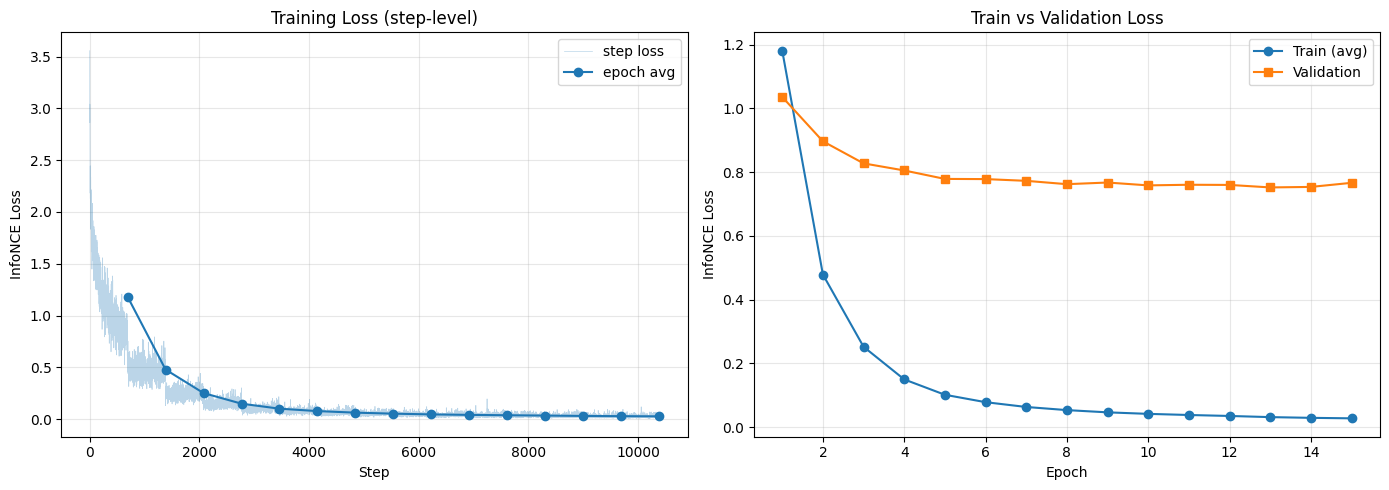

In [2]:
log_entries = [json.loads(line) for line in LOG_PATH.read_text().strip().split("\n")]

steps  = [e["step"] for e in log_entries if "train_loss" in e]
losses = [e["train_loss"] for e in log_entries if "train_loss" in e]

epoch_ends  = [e for e in log_entries if e.get("event") == "epoch_end"]
epoch_nums  = [e["epoch"] for e in epoch_ends]
epoch_train = [e["avg_train_loss"] for e in epoch_ends]
epoch_val   = [e["val_loss"] for e in epoch_ends]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: step-level training loss
axes[0].plot(steps, losses, alpha=0.3, linewidth=0.5, color="tab:blue", label="step loss")
axes[0].plot([e["step"] for e in epoch_ends], epoch_train, "o-", color="tab:blue", label="epoch avg")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("InfoNCE Loss")
axes[0].set_title("Training Loss (step-level)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: train vs validation per epoch
axes[1].plot(epoch_nums, epoch_train, "o-", label="Train (avg)")
axes[1].plot(epoch_nums, epoch_val, "s-", label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("InfoNCE Loss")
axes[1].set_title("Train vs Validation Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Training Observations

| Epoch | Train Loss | Val Loss |
|------:|-----------:|---------:|
| 1 | 1.1806 | 1.0355 |
| 2 | 0.4785 | 0.8964 |
| 3 | 0.2519 | 0.8272 |
| 5 | 0.1013 | 0.7785 |
| 10 | 0.0414 | 0.7581 |
| 13 | 0.0312 | **0.7518** |
| 15 | 0.0274 | 0.7662 |

Key observations:
- **Training loss** drops rapidly in the first 3 epochs (from 1.18 to 0.25) and continues to decrease steadily
- **Validation loss** decreases until around epoch 10–13 (minimum ~0.75) and then begins to increase slightly, indicating the onset of **overfitting**
- The gap between train and val loss widens after epoch 5, which is typical when training from scratch with a relatively small dataset
- The best checkpoint by validation loss would be around **epoch 13** (val_loss = 0.7518). For a future improvement, early stopping at epoch 13 could be beneficial

### 6.4 What the Model Learns During Training

The training objective is to learn a function that converts text into a meaningful vector where **semantic similarity = geometric closeness** in the 256-dimensional embedding space. The InfoNCE contrastive loss drives this by telling the model, for each batch: "this query matches this passage, not those other ones."

This single signal forces **every learnable component** to adapt:

1. **Embedding layer** (92% of parameters) — Starts as completely random vectors. Over training, the model learns that words like "cause", "reason", "why" should have similar embeddings because they appear in similar retrieval contexts. Words like "cold" and "flu" get closer together because they co-occur with similar queries. Importantly, nothing is hardcoded — the model discovers these relationships purely from the 88,523 training pairs.

2. **LSTM weights** (gates) — Learns to **compose** word meanings into contextual representations. For example, it learns that "cold" after "common" should produce a different hidden state than "cold" after "freezing" — one refers to a disease, the other to a temperature. The forget/input/output gates learn which words to emphasize and which to suppress when building a representation of the full text.

3. **Projection layer** — Learns which of the 512 LSTM output dimensions are most useful for the retrieval task and compresses them into 256 dimensions. It essentially learns "what information matters for matching queries to passages."

**Before training**, every text gets a random embedding, so retrieval is essentially random. **After training**, a query like "what causes a cold" ends up near a passage about "rhinovirus is the main cause of the common cold" because the model learned from the data that these should be close together.

The key insight is that **no one told the model what "cold" means** or that "cause" relates to "reason." It figured all of this out from query-passage pairs, guided only by the contrastive loss.

## 7. Evaluation

### 7.1 Evaluation Protocol

All three methods are evaluated on the **same** setup:
- **Retrieval index**: 105,793 unique passages from train + validation + test splits
- **Test queries**: 9,345 distinct queries from the test split
- **Gold standard**: all passages marked as relevant for each query

### 7.2 Metrics

- **MRR (Mean Reciprocal Rank)**: For each query, finds the rank of the first relevant document and computes $\frac{1}{\text{rank}}$. Averaged across all queries. Measures how high the first correct answer appears. Higher is better (max = 1.0).

- **Recall@k**: Fraction of queries where at least one relevant document appears in the top-$k$ results. Measures coverage at different cut-off depths. Higher is better (max = 1.0).

Ties are broken deterministically by passage index to ensure reproducibility.

### 7.3 Results

In [3]:
import pandas as pd

KS = [1, 5, 10, 50, 100]

results = {
    "TF-IDF": {"mrr": 0.5183, "recall@1": 0.4036, "recall@5": 0.6575, "recall@10": 0.7421, "recall@50": 0.8773, "recall@100": 0.9078},
    "BoW Cosine": {"mrr": 0.1972, "recall@1": 0.1346, "recall@5": 0.2575, "recall@10": 0.3196, "recall@50": 0.4642, "recall@100": 0.5279},
    "BiLSTM": {"mrr": 0.3984, "recall@1": 0.2889, "recall@5": 0.5237, "recall@10": 0.6194, "recall@50": 0.7838, "recall@100": 0.8301},
}

rows = []
for name, m in results.items():
    row = {"Method": name, "MRR": m["mrr"]}
    for k in KS:
        row[f"R@{k}"] = m[f"recall@{k}"]
    rows.append(row)

df = pd.DataFrame(rows).set_index("Method")
df

,MRR,R@1,R@5,R@10,R@50,R@100
Method,,,,,,
TF-IDF,0.5183,0.4036,0.6575,0.7421,0.8773,0.9078
BoW Cosine,0.1972,0.1346,0.2575,0.3196,0.4642,0.5279
BiLSTM,0.3984,0.2889,0.5237,0.6194,0.7838,0.8301


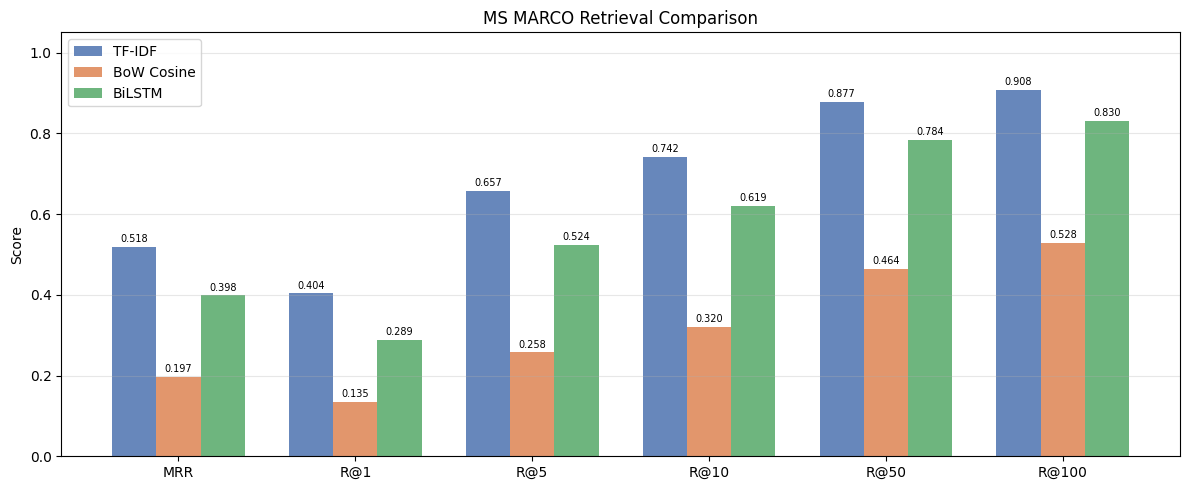

In [4]:
methods = list(results.keys())
metric_names = ["MRR"] + [f"R@{k}" for k in KS]
metric_keys  = ["mrr"] + [f"recall@{k}" for k in KS]

x = np.arange(len(metric_names))
width = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (method, color) in enumerate(zip(methods, colors)):
    vals = [results[method][mk] for mk in metric_keys]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=method, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", fontsize=7, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylabel("Score")
ax.set_title("MS MARCO Retrieval Comparison")
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Analysis of Results

**TF-IDF is the strongest method** (MRR = 0.518), which is expected:
- MS MARCO queries often share exact keywords with relevant passages
- TF-IDF with sublinear TF and IDF weighting is a very strong baseline for keyword-heavy retrieval
- It benefits from a large vocabulary (65,536 features) and does not need training

**BiLSTM outperforms BoW significantly** (MRR 0.398 vs 0.197):
- The BiLSTM captures **semantic meaning** beyond exact word matches
- It learns that "cold" (disease) and "viral respiratory infection" are related
- The qualitative examples in the evaluation notebook confirm this: for the query *"what causes a cold"*, the LSTM retrieves passages about the common cold and viruses, while BoW retrieves unrelated passages about "fatigue" and "vein symptoms" that happen to share common words

**BiLSTM vs TF-IDF gap** (MRR 0.398 vs 0.518):
- This is a known phenomenon: dense models trained from scratch on limited data often underperform strong lexical baselines
- The gap would likely narrow with: (1) more training data, (2) hard negative mining, (3) more expressive architecture (e.g., Transformer), (4) pretrained word embeddings (GloVe/Word2Vec)
- However, the BiLSTM's strength lies in **semantic understanding**, which is more valuable for queries that don't share exact keywords with relevant documents

**BoW is the weakest** (MRR = 0.197):
- Without IDF, common words dominate the similarity computation
- Included as a baseline to demonstrate the importance of IDF weighting in lexical retrieval

## 8. Book Search Demo — Qualitative Comparison

To demonstrate how the models generalize beyond MS MARCO, we test all three methods on a completely different domain: searching passages from the **Jurafsky & Martin — Speech and Language Processing** textbook (1,521 chunks of ~240 words each).

The models were **never trained on this textbook** — this tests cross-domain generalization.

### Query: *"what is word tokenization"*

**BiLSTM results:**

| Rank | Passage (shortened) |
|:----:|-----|
| #1 | *"...the probability of a word depends only on the previous word is called a Markov assumption... n-gram approximation..."* — About n-gram language models (somewhat related to words, but not tokenization) |
| #2 | *"...used to expand clitic contractions... tokenization algorithms may also tokenize multiword expressions like New York..."* — Directly about tokenization |
| #3 | *"...word error rate as a metric... automatic speech recognition..."* — About ASR word error rate (not relevant) |

**TF-IDF results:**

| Rank | Passage (shortened) |
|:----:|-----|
| #1 | *"...Collection process: How big is the data?... Regular Expressions — One of the most useful tools for text process..."* — About corpora and regex (not tokenization) |
| #2 | *"...ELIZA... the pattern-based approach to words is still relevant today in the context of tokenization, the task of separating out or tokenizing words..."* — Directly about tokenization |
| #3 | *"...Unix tools of this sort can be very handy in building quick word count statistics... Rule-based tokenization..."* — Directly about tokenization |

**DistilBERT (pretrained) results:**

| Rank | Passage (shortened) |
|:----:|-----|
| #1 | *"...Tokenization — Machine translation systems use a vocabulary that is fixed in advance... generated with subword tokenization algorithms, like the BPE algorithm..."* — Directly about tokenization |
| #2 | *"...Why tokenize the input? One reason is that converting an input to a deterministic fixed set of units... Is don't or New York one token or two?..."* — Directly about tokenization |
| #3 | *"...Masked language models like BERT, RoBERTA... encoder models are not generative models... encoder-decoder takes as input a sequence of tokens..."* — About encoder models and tokens |

### Summary

| Method | Relevant in top 5 | Observation |
|--------|:-:|---|
| **DistilBERT** | **5/5** | Best — pretrained on billions of words, deep semantic understanding |
| **TF-IDF** | 4/5 | Good — exact keyword matching on "tokenization" works well |
| **BiLSTM** | 1/5 | Weaker — trained from scratch with only 88k pairs, but still finds the right topic area |

The BiLSTM captures the general semantic neighborhood (all results are about words/language processing) but lacks the precision of a pretrained model. This is the expected trade-off when training from scratch with limited data versus leveraging pretrained representations learned from massive corpora.

## 9. Conclusion

We built a neural search engine from scratch using a **BiLSTM bi-encoder** trained with **InfoNCE contrastive loss**. The model was trained for 15 epochs on 88,523 MS MARCO query–passage pairs using a custom word-level vocabulary and no pretrained weights.

**Key findings:**
- The BiLSTM achieves **MRR = 0.398** and **Recall@10 = 0.619**, demonstrating that a neural model trained from scratch can learn meaningful semantic representations for retrieval
- TF-IDF remains a strong baseline (MRR = 0.518) due to the keyword-heavy nature of MS MARCO queries
- The BiLSTM significantly outperforms the BoW baseline (MRR 0.398 vs 0.197), confirming the value of learned semantic representations over raw word counts
- On the book search demo, the BiLSTM generalizes to an unseen domain (textbook), retrieving topically relevant passages despite never being trained on that data
- The pretrained DistilBERT model outperforms both the BiLSTM and TF-IDF on the book demo, illustrating the power of large-scale pretraining

**Potential improvements:**
- Early stopping at epoch 13 (best validation loss)
- Initializing embeddings with pretrained word vectors (GloVe)
- Hard negative mining instead of random in-batch negatives
- Multi-layer LSTM or attention-based pooling
- Hybrid retrieval: use TF-IDF for initial candidate retrieval, then re-rank with the neural model